# Generate bound curves for dSprites for all dims

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from microscope.datasets import custom_dsprites
from microscope.datasets.generic_dataset_loader import DatasetName, load_dataset
from microscope.computations_grid.data_analysis.data_analysis import (
    compute_measures_multiclass,
    plot_pairs_multiclass,
    plot_3d_pca_projections_multiclass,
    clip_results_multiclass,
    MeasureAggregates
)

## Load the measures on the dsprites datasets for all sizes

In [ ]:
normalize_for_volume = True
output_dir = Path(f"~/experiments/manifold_microscope/manifold_fitting/measures_all_datasets/dsprites_measures_vol_norm_{normalize_for_volume}").expanduser() 

measures = dict()
for number_of_dims in range(1, 5):
    output_path = output_dir / f"dsprites_{number_of_dims}.pkl"
    with open(output_path, "rb") as f:
        measures[number_of_dims] = clip_results_multiclass(pickle.load(f))

## Generate the curves

In [3]:
results_df = []

for path in Path("~/experiments/manifold_microscope/manifold_fitting/training_absolute_ratio_dl_models_fixed_test_set_mmls_FINAL").expanduser().glob("**/*.pkl"):
    dataset, method, data_perc, dims, noise, n_iter = path.parent.name.split("__")
    
    with open(path, "rb") as f:
        results = pickle.load(f)

    results_df.append(dict(
        dataset=dataset,
        method=method,
        data_perc=float(data_perc), 
        dims=int(dims), 
        noise=float(noise), 
        n_iter=int(n_iter),
        number_of_train_points=results["number_of_train_points"],
        number_of_test_points=results["number_of_test_points"],
        hausdorff_distance=results["hausdorff_distance"],
        avg_distance=results["pointwise_distances"].mean()
    ))

results_df = pd.DataFrame(results_df)

In [4]:
results_df.shape

(212, 10)

In [5]:
results_df.head()

,dataset,method,data_perc,dims,noise,n_iter,number_of_train_points,number_of_test_points,hausdorff_distance,avg_distance
0,extended_coil20,MMLS,0.4,1,0.0,1,100,108,12.085001,7.251779
1,custom_dsprites_balanced,MMLS,0.2,2,0.0,2,107,230,4.242675,1.630946
2,custom_dsprites_balanced,MMLS,0.3,1,0.0,1,10,14,7.286685,4.055747
3,extended_coil20,MMLS,0.6,2,0.0,1,3156,500,10.190563,6.316925
4,custom_dsprites_balanced,MMLS,0.7,4,0.0,1,137275,500,2.815711,0.694557


### Plot the N vs distance curves

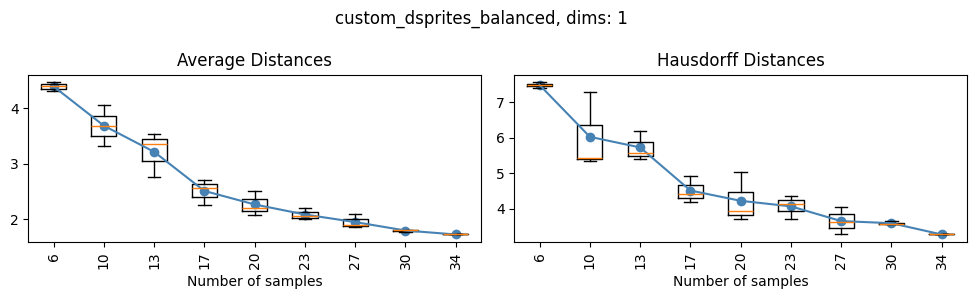

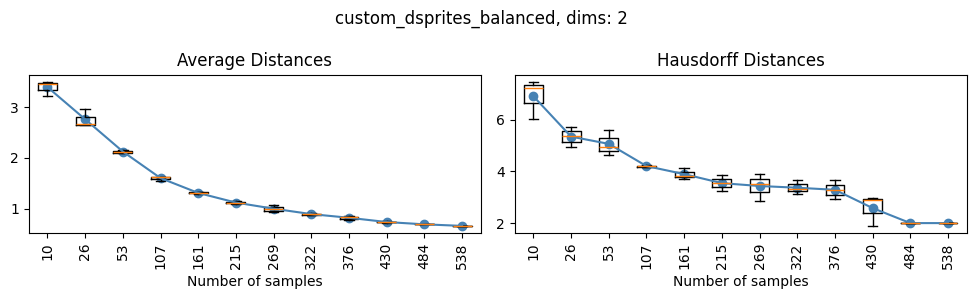

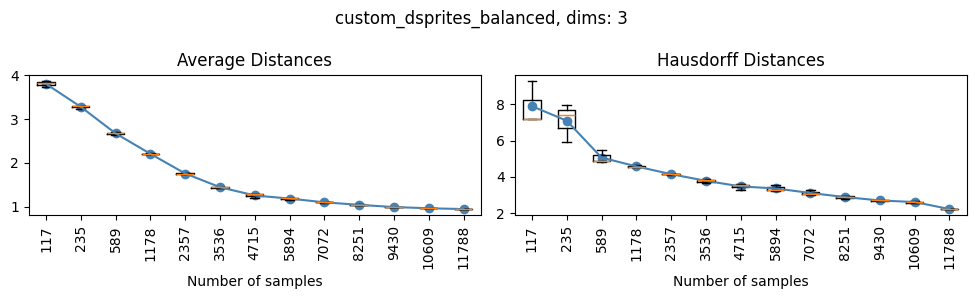

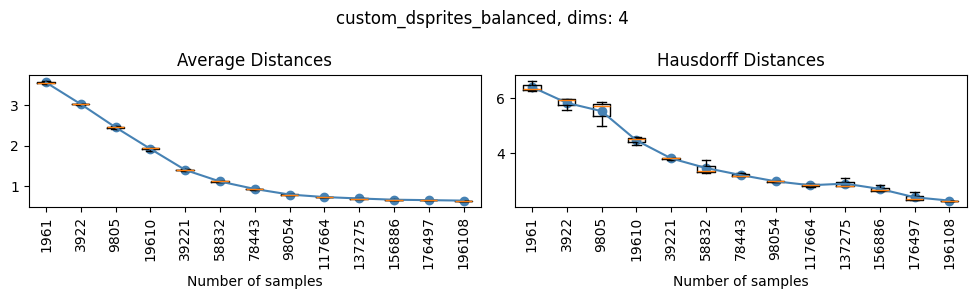

In [6]:
labels_every_n = 1

for dataset_name in ["custom_dsprites_balanced"]:
    for dim in [1, 2, 3, 4]:
        dataset_results = (
            results_df
            [(results_df["dataset"] == dataset_name) & (results_df["dims"] == dim)]
            .groupby("number_of_train_points")
            .agg(list)
        )
    
        avg_all = dataset_results["avg_distance"]
        haus_all = dataset_results["hausdorff_distance"]
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        plt.suptitle(f"{dataset_name}, dims: {dim}")
        ax[0].set_title("Average Distances")
        ax[0].boxplot(avg_all)
        ax[0].set_xticklabels(dataset_results.index)
        ax[0].plot(1 + np.arange(len(avg_all)), avg_all.map(np.mean), color="steelblue")
        ax[0].scatter(1 + np.arange(len(avg_all)), avg_all.map(np.mean), color="steelblue")
        ax[0].set_xlabel("Number of samples")
        ax[0].tick_params(axis='x', labelrotation=90)
        for i, label in enumerate(ax[0].xaxis.get_ticklabels()):
            if not i % labels_every_n == 0:
                label.set_visible(False)
        
        ax[1].set_title("Hausdorff Distances")
        ax[1].boxplot(haus_all)
        ax[1].set_xticklabels(dataset_results.index)
        ax[1].plot(1 + np.arange(len(haus_all)), haus_all.map(np.mean), color="steelblue")
        ax[1].scatter(1 + np.arange(len(haus_all)), haus_all.map(np.mean), color="steelblue")
        ax[1].set_xlabel("Number of samples")
        ax[1].tick_params(axis='x', labelrotation=90)
        for i, label in enumerate(ax[1].xaxis.get_ticklabels()):
            if not i % labels_every_n == 0:
                label.set_visible(False)

        plt.tight_layout()
        plt.show()

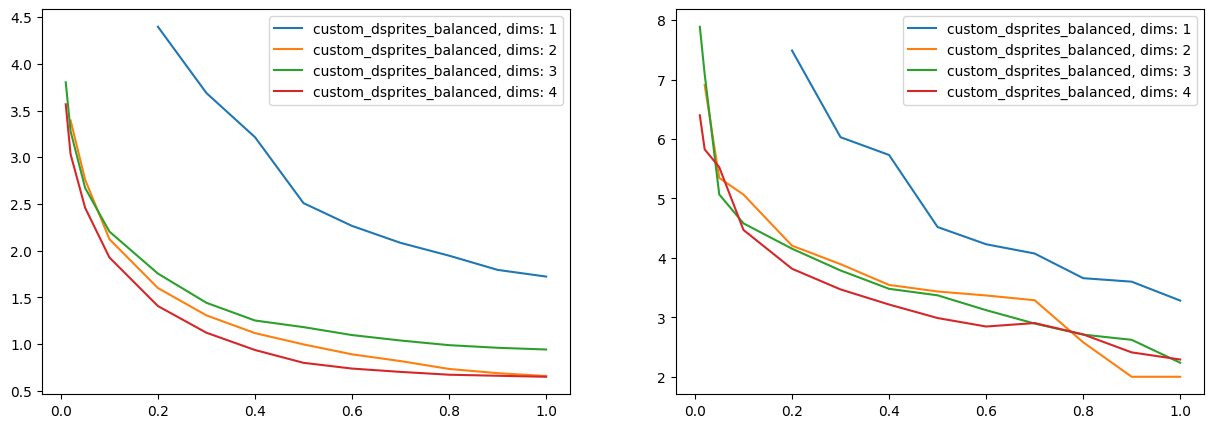

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for dataset_name in ["custom_dsprites_balanced"]:
    for dim in [1, 2, 3, 4]:
        if dim == 4 and dataset_name == "extended_coil20":
            continue
            
        dataset_results = (
            results_df
            [(results_df["dataset"] == dataset_name) & (results_df["dims"] == dim)]
            .groupby("data_perc")
            .agg(list)
        )

        name = f"{dataset_name}, dims: {dim}"

        avg_all = dataset_results["avg_distance"]
        haus_all = dataset_results["hausdorff_distance"]
    
        ax[0].plot(dataset_results.index, avg_all.map(np.mean), label=name)
        ax[1].plot(dataset_results.index, haus_all.map(np.mean), label=name)
        ax[0].legend()
        ax[1].legend()
            
plt.show()

## Estimate upper and lower bounds

In [8]:
def robust_lower_bound(f_values, g, x, q=0.01):
    lower_bound = g(x)
    return np.quantile(f_values / lower_bound, q=q)

def robust_upper_bound(f_values, g, x, q=0.99):
    upper_bound = g(x)
    return np.quantile(f_values / upper_bound, q=q)

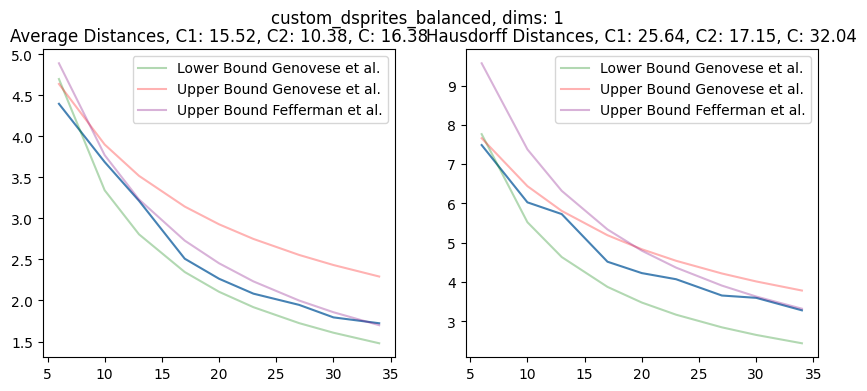

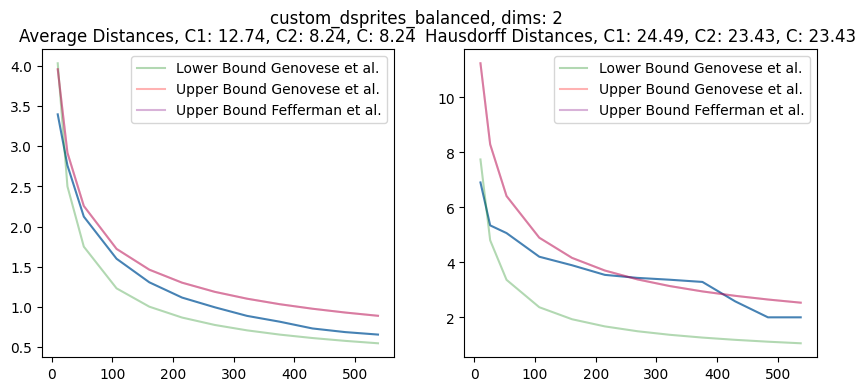

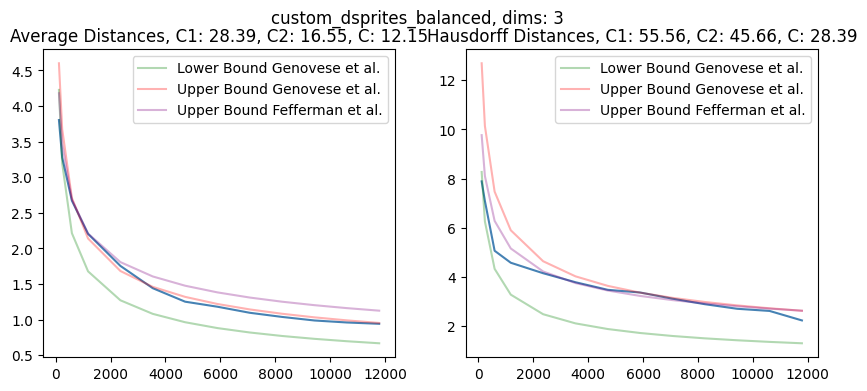

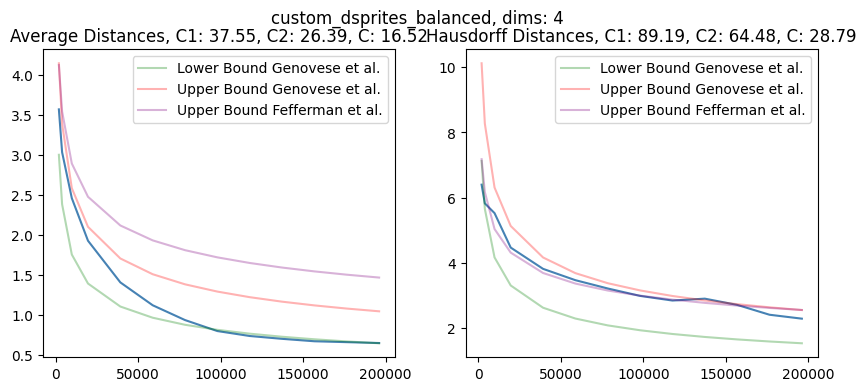

In [9]:
def g_lower_genovese(x): 
    return (1/x)**(2/(2 + d))
def g_upper_genovese(x): 
    return (np.log(x)/x)**(2/(2 + d))

def g_upper_fefferman(x): 
    return (np.log(x) / x)**(1 / d)

for dataset_name in ["custom_dsprites_balanced"]:
    for d in [1, 2, 3, 4]:
        name = f"{dataset_name}, dims: {d}"
        
        dataset_results = (
            results_df
            [(results_df["dataset"] == dataset_name) & (results_df["dims"] == d)]
            .groupby("number_of_train_points")
            .agg(list)
        )
    
        avg_all = dataset_results["avg_distance"]
        haus_all = dataset_results["hausdorff_distance"]
        tau = np.min(list(measures[d].measure_aggregates.normalized_min_reaches.values()))
        
        f_values_avg = np.array(avg_all.map(np.mean))
        x = np.array(dataset_results.index)

        x_log = np.log(x).reshape(-1, 1)
        y_log = np.log(f_values_avg)
        
        # linear regression
        reg = LinearRegression().fit(x_log, y_log)
        alpha_fit = -reg.coef_[0]
        C_fit = np.exp(reg.intercept_)
        f_vals_fitted = C_fit * x**(-alpha_fit)
    
        C1 = robust_lower_bound(f_vals_fitted, g_lower_genovese, x)
        C2 = robust_upper_bound(f_vals_fitted, g_upper_genovese, x)
        C = robust_upper_bound(f_vals_fitted, g_upper_fefferman, x)
        
        yl = C1 * g_lower_genovese(x)
        yu = C2 * g_upper_genovese(x)
        yu_f = C * g_upper_fefferman(x)
    
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        plt.suptitle(name)
    
        ax[0].set_title(f"Average Distances, C1: {C1:.2f}, C2: {C2:.2f}, C: {C:.2f}")
        ax[0].plot(x, f_values_avg, color="steelblue")
        # ax[0].plot(x, f_vals_fitted, color="steelblue")
        ax[0].plot(x, yl, color="green", alpha=0.3, label="Lower Bound Genovese et al.")
        ax[0].plot(x, yu, color="red", alpha=0.3, label="Upper Bound Genovese et al.")
        ax[0].plot(x, yu_f, color="purple", alpha=0.3, label="Upper Bound Fefferman et al.")
        # ax[0].set_ylim((0, 1.05*f_values_avg.max()))
        ax[0].legend()
    
        f_values_haus = np.array(haus_all.map(np.mean))

        x_log = np.log(x).reshape(-1, 1)
        y_log = np.log(f_values_haus)
        
        # linear regression
        reg = LinearRegression().fit(x_log, y_log)
        alpha_fit = -reg.coef_[0]
        C_fit = np.exp(reg.intercept_)
        f_vals_fitted = C_fit * x**(-alpha_fit)
        
        C1 = robust_lower_bound(f_vals_fitted, g_lower_genovese, x)
        C2 = robust_upper_bound(f_vals_fitted, g_upper_genovese, x)
        C = robust_upper_bound(f_vals_fitted, g_upper_fefferman, x)
        
        yl = C1 * g_lower_genovese(x)
        yu = C2 * g_upper_genovese(x)
        yu_f = C * g_upper_fefferman(x)
    
        ax[1].set_title(f"Hausdorff Distances, C1: {C1:.2f}, C2: {C2:.2f}, C: {C:.2f}")
        ax[1].plot(x, f_values_haus, color="steelblue")
        # ax[1].plot(x, f_vals_fitted, color="steelblue")
        ax[1].plot(x, yl, color="green", alpha=0.3, label="Lower Bound Genovese et al.")
        ax[1].plot(x, yu, color="red", alpha=0.3, label="Upper Bound Genovese et al.")
        ax[1].plot(x, yu_f, color="purple", alpha=0.3, label="Upper Bound Fefferman et al.")
        # ax[1].set_ylim((0, 1.05*f_values_haus.max()))
        ax[1].legend()
        
        plt.show()

## Polish and export bounds

In [10]:
def robust_lower_bound(f_values, g, x, q=0.01):
    lower_bound = g(x)
    return np.quantile(f_values / lower_bound, q=q)

def robust_upper_bound(f_values, g, x, q=0.99):
    upper_bound = g(x)
    return np.quantile(f_values / upper_bound, q=q)

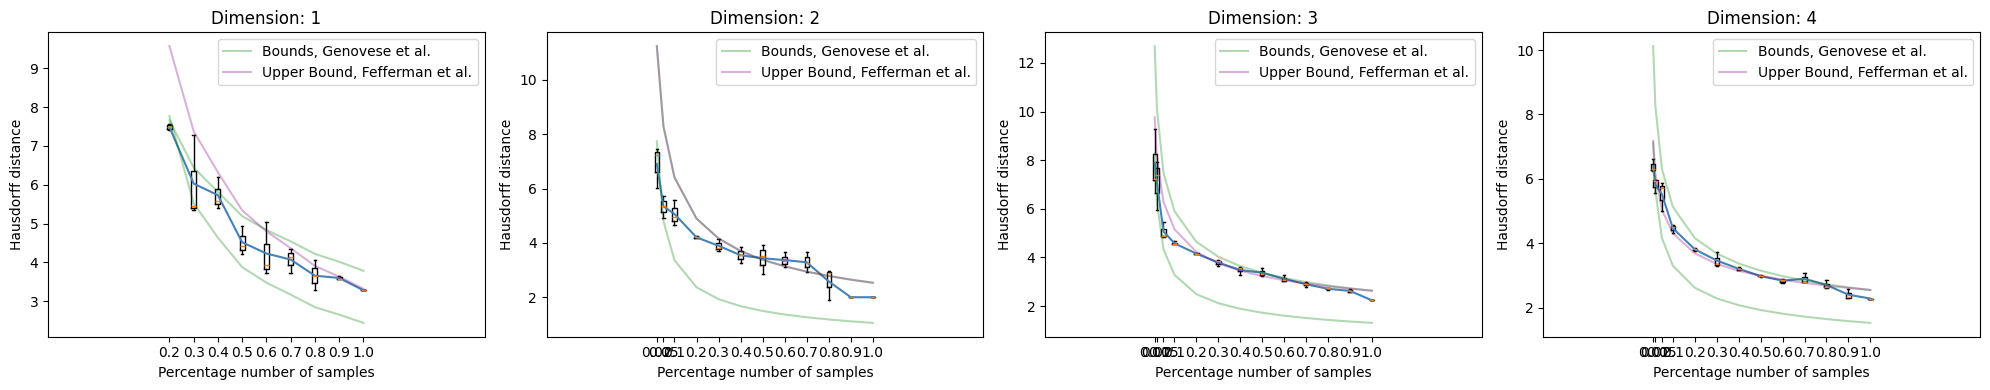

In [11]:
def g_lower_genovese(x): 
    return (1/x)**(2/(2 + d))
def g_upper_genovese(x): 
    return (np.log(x)/x)**(2/(2 + d))

def g_upper_fefferman(x): 
    return (np.log(x) / x)**(1 / d)
    
dataset_name = "custom_dsprites_balanced"

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

curves_to_export = {}

for d in [1, 2, 3, 4]:
    name = f"{dataset_name}, dims: {d}"
    
    dataset_results = (
        results_df
        [(results_df["dataset"] == dataset_name) & (results_df["dims"] == d)]
        .groupby("number_of_train_points")
        .agg(list)
    )

    haus_all = dataset_results["hausdorff_distance"]
    tau = np.min(list(measures[d].measure_aggregates.normalized_min_reaches.values()))
    
    f_values_haus = np.array(haus_all.map(np.mean))
    x = np.array(dataset_results.index)

    x_perc = np.array(dataset_results["data_perc"].str[0])

    x_log = np.log(x).reshape(-1, 1)
    y_log = np.log(f_values_haus)
    
    # linear regression
    reg = LinearRegression().fit(x_log, y_log)
    alpha_fit = -reg.coef_[0]
    C_fit = np.exp(reg.intercept_)
    f_vals_fitted = C_fit * x**(-alpha_fit)
    
    C1 = robust_lower_bound(f_vals_fitted, g_lower_genovese, x)
    C2 = robust_upper_bound(f_vals_fitted, g_upper_genovese, x)
    C = robust_upper_bound(f_vals_fitted, g_upper_fefferman, x)
    
    yl = C1 * g_lower_genovese(x)
    yu = C2 * g_upper_genovese(x)
    yu_f = C * g_upper_fefferman(x)

    curves_to_export[f"dim_{d}"] = {
        "x_perc": x_perc,
        "x": x, 
        "empirical_all_repetitions": haus_all, 
        "empirical": f_values_haus, 
        "lower_genovese": yl, 
        "upper_genovese": yu, 
        "upper_fefferman": yu_f
    }
    
    ax = axes[d - 1]
    # ax.set_title(f"C1: {C1:.2f}, C2: {C2:.2f}, C: {C:.2f}")
    ax.set_title(f"Dimension: {d}")
    ax.boxplot(haus_all, positions=x_perc, widths=0.02)
    ax.plot(x_perc, f_values_haus, color="steelblue")
    # ax[1].plot(x, f_vals_fitted, color="steelblue")
    ax.plot(x_perc, yl, color="green", alpha=0.3, label="Bounds, Genovese et al.")
    ax.plot(x_perc, yu, color="green", alpha=0.3)
    ax.plot(x_perc, yu_f, color="purple", alpha=0.3, label="Upper Bound, Fefferman et al.")
    # ax[1].set_ylim((0, 1.05*f_values_haus.max()))
    ax.set_xlabel("Percentage number of samples")
    ax.set_ylabel("Hausdorff distance")
    ax.legend()

np.savez("dsprites_dim_bounds.npz", **curves_to_export)

plt.tight_layout()
plt.savefig("dsprites_dim_bounds.png", dpi=200)
plt.show()